# PulseStream — model experiments
Explores the ticket data, evaluates the classifier honestly, and looks at where it fails.
Run from the `notebooks/` folder (or anywhere — paths are resolved from the project root).

In [1]:
import sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
train = pd.read_csv(ROOT / "data" / "tickets.csv")
hold = pd.read_csv(ROOT / "data" / "holdout.csv")
print(len(train), "train rows,", len(hold), "holdout rows")
train.sample(5, random_state=1)

381 train rows, 25 holdout rows


,text,label
244,"Love the new dark mode, great update, any ideas?",praise
180,This is the best app I have used all year!,praise
277,"Hello team, where is the option to change the ...",support
185,"Hi there, uploads fail at 99 percent with a ne...",bug
233,Quick question: the date picker shows the wron...,bug


## 1. Data: label balance and text length

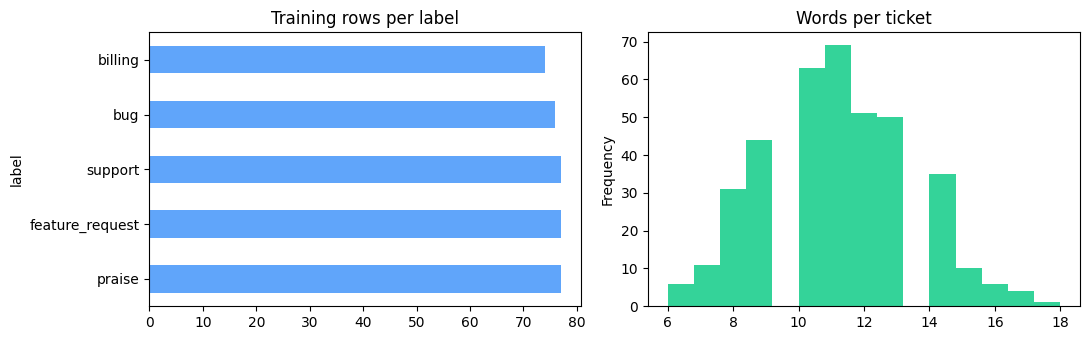

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
train.label.value_counts().plot.barh(ax=ax[0], color="#60a5fa"); ax[0].set_title("Training rows per label")
train.text.str.split().str.len().plot.hist(ax=ax[1], bins=15, color="#34d399"); ax[1].set_title("Words per ticket")
plt.tight_layout(); plt.show()

## 2. Baseline: TF-IDF + Logistic Regression
Cross-validation on the training set **overstates** quality, because the synthetic tickets reuse each sentence with
small phrasing changes. The hand-written holdout set is the honest number.

In [3]:
def make(C=5.0, ngram=(1, 2)):
    return Pipeline([("tfidf", TfidfVectorizer(ngram_range=ngram, sublinear_tf=True)),
                     ("clf", LogisticRegression(C=C, max_iter=2000))])

pipe = make().fit(train.text, train.label)
pred = pipe.predict(hold.text)
print("CV macro-F1 (inflated):", round(cross_val_score(make(), train.text, train.label, cv=5, scoring="f1_macro").mean(), 3))
print("Holdout accuracy:", round(accuracy_score(hold.label, pred), 3), "| macro-F1:", round(f1_score(hold.label, pred, average="macro"), 3))
print(classification_report(hold.label, pred, zero_division=0))

CV macro-F1 (inflated): 1.0
Holdout accuracy: 0.84 | macro-F1: 0.837
                 precision    recall  f1-score   support

        billing       0.75      0.60      0.67         5
            bug       1.00      0.80      0.89         5
feature_request       0.71      1.00      0.83         5
         praise       1.00      0.80      0.89         5
        support       0.83      1.00      0.91         5

       accuracy                           0.84        25
      macro avg       0.86      0.84      0.84        25
   weighted avg       0.86      0.84      0.84        25



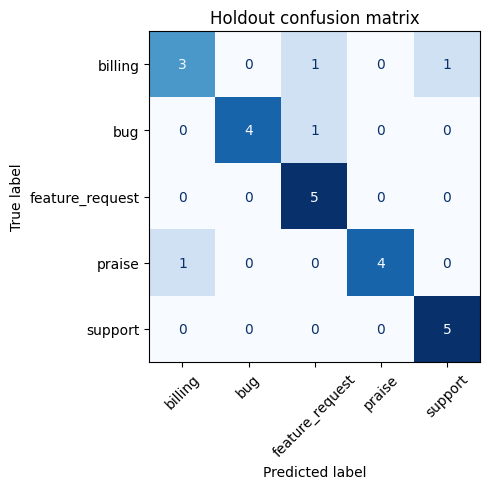

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(hold.label, pred, ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Holdout confusion matrix"); plt.tight_layout(); plt.show()

## 3. Error analysis — what does it get wrong, and how sure was it?

In [5]:
proba = pipe.predict_proba(hold.text)
out = hold.assign(pred=pred, confidence=proba.max(axis=1).round(2))
out[out.label != out.pred].sort_values("confidence", ascending=False)

,text,label,pred,confidence
2,Login fails with a weird message about a bad t...,bug,feature_request,0.46
6,Please send me an invoice with our company VAT...,billing,feature_request,0.39
8,How much will I pay if I add five more seats,billing,support,0.35
13,Such a smooth experience from start to finish,praise,billing,0.27


Confidence vs correctness — a useful dashboard threshold is where wrong answers start to dominate.

In [6]:
out["correct"] = out.label == out.pred
print(out.groupby(pd.cut(out.confidence, [0, .3, .5, .7, 1.0]), observed=True).correct.agg(["mean", "count"]).round(2))

            mean  count
confidence             
(0.0, 0.3]   0.0      1
(0.3, 0.5]   0.7     10
(0.5, 0.7]   1.0      7
(0.7, 1.0]   1.0      7


## 4. Quick hyper-parameter sweep (scored on the holdout set)

In [7]:
rows = []
for C in [0.5, 1, 5, 20, 100]:
    for ngram in [(1, 1), (1, 2)]:
        p = make(C, ngram).fit(train.text, train.label).predict(hold.text)
        rows.append({"C": C, "ngram": ngram, "holdout_acc": accuracy_score(hold.label, p), "macro_f1": f1_score(hold.label, p, average="macro")})
pd.DataFrame(rows).sort_values("macro_f1", ascending=False).round(3)

,C,ngram,holdout_acc,macro_f1
6,20.0,"(1, 1)",0.88,0.879
0,0.5,"(1, 1)",0.88,0.876
1,0.5,"(1, 2)",0.88,0.876
3,1.0,"(1, 2)",0.88,0.876
2,1.0,"(1, 1)",0.84,0.837
4,5.0,"(1, 1)",0.84,0.837
5,5.0,"(1, 2)",0.84,0.837
7,20.0,"(1, 2)",0.84,0.837
9,100.0,"(1, 2)",0.84,0.837
8,100.0,"(1, 1)",0.84,0.834


## 5. Optional: sentence embeddings
Needs `pip install -r requirements-embeddings.txt` (downloads a model, ~100 MB + PyTorch). Skipped automatically if not installed.

In [8]:
try:
    sys.path.insert(0, str(ROOT))
    from model.features import EmbeddingVectorizer
    emb = Pipeline([("embed", EmbeddingVectorizer()), ("clf", LogisticRegression(C=5, max_iter=2000))])
    p = emb.fit(train.text, train.label).predict(hold.text)
    print("Embeddings holdout accuracy:", round(accuracy_score(hold.label, p), 3), "| macro-F1:", round(f1_score(hold.label, p, average="macro"), 3))
except ImportError:
    print("sentence-transformers not installed - skipping")

sentence-transformers not installed - skipping


## 6. Takeaways
- Wording unseen at training time drags TF-IDF down; `billing` is the weakest class.
- Low-confidence predictions are much less reliable — the dashboard's "low" flag (<50%) is justified.
- Next: real labelled tickets, and compare against the embeddings model above.